In [ ]:
# @title
!pip install pypsa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.2/346.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.2/116.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 810.4/810.4 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.3 MB/s eta 0:00:00
  Attempting uninstall: polars
    Found existing installation: polars 1.31.0
    Uninstalling polars-1.31.0:
      Successfully uninstalled polars-1.31.0


In [ ]:
# @title
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
import pickle

In [ ]:
grid_technical = pd.read_excel('/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx', sheet_name = 'Grid_technical')
grid_topology = pd.read_excel('/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx', sheet_name = 'Grid_topology')
node_data = pd.read_excel('/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx', sheet_name = 'Node_data')
node_data.head()

,Node-ID,Country,State,Dena zone,z6,Load share\noff-peak,Load share\npeak,Run-of-river,Photovoltaic,Onshore\nwind,Offshore\nwind,Biomass,Geothermal,Coordinates,not used in\nmodel
0,n001,DK,DK,95,DK,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,55.037,9.269
1,n002,DK,DK,95,DK,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,54.940,9.390
2,n003,DE,DE_SH,21,DE_NW,0.000732,0.000819,0.11164,196.108384,518.092072,NaN,48.68578,NaN,54.716,9.317
3,n004,DE,DE_SH,21,DE_NW,0.001275,0.001426,0.17500,30.662928,37.447600,NaN,19.11200,NaN,54.349,10.061
4,n005,DE,DE_SH,21,DE_NW,0.001517,0.001696,0.06000,11.891444,20.055000,NaN,2.61700,NaN,54.340,10.177


In [ ]:
network = pypsa.Network()
network.set_snapshots(pd.date_range("2018-01-01 00:00:00", "2018-01-07 23:00:00", freq = 'h'))

In [ ]:
V_REF = 380
for i in range(0, len(node_data)):
  network.add("Bus",
              name = node_data.iloc[i]['Node-ID'],
              v_nom = V_REF,
              x = node_data.iloc[i]['Coordinates'],
              y = node_data.iloc[i]['not used in\nmodel'])

In [ ]:
for i in range(len(grid_technical)):
    row_topo = grid_topology.iloc[i]
    row_tech = grid_technical.iloc[i]

    plusone_col = grid_topology.columns[row_topo.eq(1)].tolist()
    minusone_col = grid_topology.columns[row_topo.eq(-1)].tolist()

    power_val = row_tech['power']
    circuit_val = row_tech['circuits'] if pd.notna(row_tech['circuits']) else 1
    total_capacity = power_val * circuit_val

    network.add("Line",
                name = row_tech[0],
                bus0 = plusone_col[0],
                bus1 = minusone_col[0],
                x = row_tech['reactance'],
                r = row_tech['resistance'],
                s_nom = total_capacity) # <--- Correct limit added here

print(f"Successfully added {len(grid_technical)} lines with multi-circuit capacities.")

/tmp/ipython-input-3420330424.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3420330424.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3420330424.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3420330424.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

Successfully added 697 lines with multi-circuit capacities.


/tmp/ipython-input-3420330424.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3420330424.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3420330424.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3420330424.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

In [ ]:
node_data['Load share\npeak'] = pd.to_numeric(node_data['Load share\npeak'], errors='coerce')
node_data['Load share\npeak'] = node_data['Load share\npeak'].fillna(0)


demand = pd.read_excel('/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Actual_consumption_201801010000_201901010600_Hour.xlsx').iloc[:168]
demand = pd.read_excel('/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx', sheet_name = 'H_demand').iloc[1:169]

demand.index = network.snapshots
demand.head()

for index, row in node_data.iterrows():
  load_share = row['Load share\npeak']
  load_at_bus = demand['Mwh'] * load_share
  bus_name = row['Node-ID']
  network.add("Load", f"Load_{bus_name}",
              bus = bus_name,
              p_set = load_at_bus)



In [ ]:
generators_con = pd.read_excel("/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx", sheet_name = 'Plant_con')
generators_psp = pd.read_excel("/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx", sheet_name = 'Plant_psp')
prices_h = pd.read_excel('/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx', sheet_name = 'H_price').iloc[:168]


generators_con['Emission'] = pd.to_numeric(generators_con['Emission'], errors='coerce').fillna(0)
generators_con['Efficiency'] = pd.to_numeric(generators_con['Efficiency'], errors='coerce').fillna(0.33) # Fallback for Nuc
generators_con['Capacity\n[MW]'] = pd.to_numeric(generators_con['Capacity\n[MW]'], errors='coerce').fillna(0)

In [ ]:
generators_con = generators_con.dropna(subset = ['Fuel', 'Emission', 'Efficiency'])

for index, generator in generators_con.iterrows():
    fuel_price = prices_h[generator['Fuel']]
    co2_price = prices_h['co2']

    # Ensure efficiency is not zero to avoid division by zero
    efficiency = generator['Efficiency'] if generator['Efficiency'] != 0 else 1e-6 # Use a small non-zero value

    cost_per_Mwh = (fuel_price + co2_price * generator['Emission']) / efficiency
    cost_per_Mwh.index = network.snapshots

    if generator['Fuel'] != 'nuc':
      network.add("Generator",
                  name = generator['Plant-ID'],
                  bus = generator['Node No'],
                  p_nom = generator['Capacity\n[MW]'],
                  marginal_cost = cost_per_Mwh,
                  carrier = generator['Fuel']
                  )

In [ ]:
print(network.loads_t.p_set.sum().sum())
print(network.generators.p_nom.sum())

10273028.234703882
76274.95140068595


In [ ]:
import pandas as pd
import numpy as np

h_wind = pd.read_excel('/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx', sheet_name = 'H_wind').iloc[:168]
h_pv = pd.read_excel('/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx', sheet_name = 'H_pv').iloc[:168]

node_data.columns = [c.replace('\n', ' ').strip() for c in node_data.columns]
node_data['Dena zone'] = node_data['Dena zone'].astype(str)

for index, node in node_data.iterrows():
    node_id = str(node['Node-ID'])
    zone = str(int(float(node['Dena zone']))) if pd.notna(node['Dena zone']) else None

    techs = {
        'Onshore wind': ('onshore', h_wind),
        'Photovoltaic': ('pv', h_pv),
        'Offshore wind': ('offshore', h_wind)
    }

    for tech_col, (carrier, profile_df) in techs.items():
        capacity = pd.to_numeric(node.get(tech_col, 0), errors='coerce')

        if capacity > 0 and zone in profile_df.columns:
            profile = profile_df[zone].fillna(0).values

            network.add("Generator",
                        name=f"{node_id}_{carrier}",
                        bus=node_id,
                        p_nom=capacity,
                        p_max_pu=profile,
                        marginal_cost=0,
                        carrier=carrier)

print("Successfully added renewable fleet.")

Successfully added renewable fleet.


In [ ]:
import pandas as pd

# Load the import data
h_import = pd.read_excel('/content/drive/MyDrive/citadel recruiting/german_networkanalysis/Data_Input.xlsx', sheet_name = 'H_import').iloc[:168]

# Ensure the 'Unnamed: 0' (time) is not treated as a data column and fill NaNs with 0
import_profiles = h_import.set_index('Unnamed: 0').fillna(0) # <--- Fix: Missing values become 0

SCARCITY_PRICE = 500

for node_id in import_profiles.columns:
    if node_id in network.buses.index:
        # 1. Add the Standard Import (The 'Data-Driven' supply)
        # This uses your Excel profiles and is capped at max_import_capacity
        max_import_capacity = import_profiles[node_id].max()
        if max_import_capacity > 0:
            normalized_profile = import_profiles[node_id] / max_import_capacity
            network.add("Generator",
                        name=f"import_{node_id}",
                        bus=node_id,
                        p_nom=max_import_capacity,
                        p_max_pu=normalized_profile.values,
                        marginal_cost=100,
                        carrier="import")

        # 2. Add the Border Slack (The 'Emergency' supply)
        # This has UNLIMITED capacity but a PUNITIVE price.
        # It triggers only if the 'Standard Import' and local gen are insufficient.
        network.add("Generator",
                    name=f"slack_border_{node_id}",
                    bus=node_id,
                    p_nom=1e6, # Massive capacity
                    marginal_cost=SCARCITY_PRICE,
                    carrier="emergency_slack")

print("Successfully mapped standard imports and emergency slack to border nodes.")

Successfully mapped standard imports and emergency slack to border nodes.


In [ ]:
for bus_id in network.buses.index:
    network.add("Generator",
                f"mismatch_{bus_id}",
                bus=bus_id,
                p_nom=1e6, # Massive capacity to ensure feasibility
                marginal_cost=20000, # 20,000 EUR/MWh
                carrier="mismatch")



In [ ]:
network.sanitize()
network.optimize(solver_name='highs')

/tmp/ipython-input-2189105538.py:2: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 38.24it/s]


('ok', 'optimal')

In [ ]:
# Extract the shadow prices (LMPs) for every bus across all hours
# Units: EUR / MWh
lmps = network.buses_t.marginal_price

# Calculate the average price per node to see regional trends
average_regional_price = lmps.mean()

print(average_regional_price)

name
n001     56.064677
n002     56.064677
n003     56.064677
n004     56.064677
n005     56.064677
           ...    
n434    179.534970
n435    233.271244
n436    232.737976
n437    232.945756
n438    179.157428
Length: 438, dtype: float64


In [ ]:
import pickle

filename = 'lmpswithoutnuclear.pkl'

with open(filename, 'wb') as file:
    # Use pickle.dump() to serialize the object and write it to the file
    pickle.dump(lmps, file)


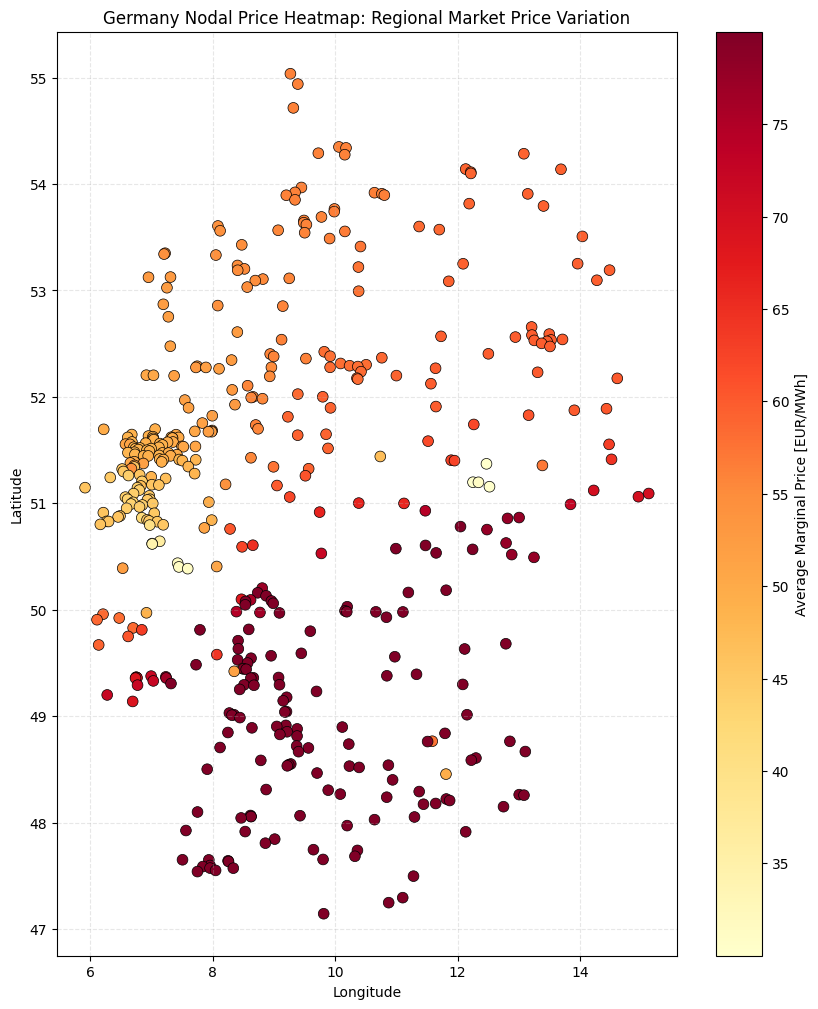

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd

# 1. Prepare coordinates
node_coords = node_data.set_index('Node-ID')[['Coordinates', 'not used in model']]
node_coords.columns = ['lat', 'lon']

# 2. Extract price data (using the mean over 24h is usually more representative)
plot_data = network.buses_t.marginal_price.mean()

# 3. Create Visualization
plt.figure(figsize=(10, 12))

# THE FIX: Tighten the range to [30, 150] and remove LogNorm for a linear scale
# This will highlight the subtle North vs. South price delta
sc = plt.scatter(node_coords['lon'], node_coords['lat'],
                 c=plot_data,
                 cmap='YlOrRd',
                 vmin=30, vmax=80, # Focused range for market prices
                 s=60, edgecolors='black', linewidth=0.5)

# Add colorbar
cb = plt.colorbar(sc, label='Average Marginal Price [EUR/MWh]')
# Set more granular ticks for the new range
cb.set_ticks([35, 40, 45, 50, 55, 60, 65, 70, 75])

plt.title('Germany Nodal Price Heatmap: Regional Market Price Variation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the data
# Assuming the PKL contains a DataFrame where:
# Index = Timestamps, Columns = Node IDs, Values = LMPs
df_with = pd.read_pickle('/content/lmpswithnuclear.pkl')
df_without = pd.read_pickle('/content/lmpswithoutnuclear.pkl')

def plot_pdc(df_w, df_wo, node_name):
    # Sort prices descending to create the duration curve
    prices_w = sorted(df_w[node_name].values, reverse=True)
    prices_wo = sorted(df_wo[node_name].values, reverse=True)

    # X-axis is the percentage of time (0 to 100%)
    x = np.linspace(0, 100, len(prices_w))

    plt.figure(figsize=(10, 6))
    plt.plot(x, prices_w, label='With Nuclear', color='blue', linewidth=2)
    plt.plot(x, prices_wo, label='Without Nuclear', color='red', linestyle='--', linewidth=2)

    plt.title(f"Price Duration Curve: {node_name}")
    plt.ylabel("LMP (€/MWh)")
    plt.xlabel("Percentage of Time (%)")
    plt.yscale('log') # Use log scale if you have 500 or 2000 slack prices
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

# Example: Plot for a Southern Node (e.g., Munich/Stuttgart)
# Calculate mean and std for every node
stats_with = pd.DataFrame({'mean': df_with.mean(), 'std': df_with.std()})
stats_without = pd.DataFrame({'mean': df_without.mean(), 'std': df_without.std()})

# Calculate the % increase in Volatility
stats_without['volatility_jump'] = (stats_without['std'] / stats_with['std'] - 1) * 100

# Top 5 most "unstable" regions after the ban
print("Top 5 Volatility Hotspots:")
print(stats_without['volatility_jump'].sort_values(ascending=False).head(20))

# Select a northern node (exporter) and southern node (importer)
north_node = 'n065'
south_node = 'n350'

# Calculate the basis (Spread)
spread_with = df_with[south_node] - df_with[north_node]
spread_without = df_without[south_node] - df_without[north_node]

print(f"Average North-South Spread (With Nuke): {spread_with.mean():.2f} €/MWh")
print(f"Average North-South Spread (No Nuke): {spread_without.mean():.2f} €/MWh")

Top 5 Volatility Hotspots:
name
n321    4589.634098
n353    2313.092818
n357    2313.092818
n354    2313.092818
n337    1544.927612
n351    1395.431132
n346    1336.529216
n365    1157.518613
n342    1129.993494
n339    1129.993494
n349    1129.993494
n323    1080.752908
n328    1052.427332
n376    1047.194520
n350    1024.628980
n347    1016.810290
n319    1006.176572
n358     972.434662
n359     955.826800
n361     955.826800
Name: volatility_jump, dtype: float64
Average North-South Spread (With Nuke): 16.69 €/MWh
Average North-South Spread (No Nuke): 128.63 €/MWh
